# Regularized Regression for Term Project

## IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

## Reading the datasets

In [3]:
# Read the CSV file into a DataFrame
healthinsprem = pd.read_csv('medical_insurance.csv')
healthinsnoprem = pd.read_csv('insurance.csv')


In [4]:
Xprem = pd.get_dummies(healthinsprem.drop('premium', axis=1)).astype(float)
yprem = healthinsprem['premium']
Xnoprem = pd.get_dummies(healthinsnoprem.drop('charges', axis=1)).astype(float)
ynoprem = healthinsnoprem['charges']

## LaTex Tables and Plots

In [5]:
def LatexTableRidge(y_actual, y_test, y_pred_in_sample, y_pred_split_test, k, data_name):
    # Get the number of observations (m) or (t) for the test set
    m = len(y_actual)  # Number of observations in the original dataset
    t = len(y_test)  # Number of observations in the test set

    # Calculate SSR (Sum of Squared Residuals)
    ssr_in_sample = np.sum((y_actual - y_pred_in_sample)**2)
    ssr_test = np.sum((y_test - y_pred_split_test)**2)

    # Calculate SST (Total Sum of Squares)
    sst_in_sample = np.sum((y_actual - np.mean(y_actual))**2)
    sst_test = np.sum((y_test - np.mean(y_test))**2)

    # Compute R-squared
    r_squared_in_sample = 1 - (ssr_in_sample / sst_in_sample)
    r_squared_test = 1 - (ssr_test / sst_test)

    # Calculate Adjusted R-squared
    r_squared_adj_in_sample = 1 - (1 - r_squared_in_sample) * (m) / (m - k)
    r_squared_adj_test = 1 - (1 - r_squared_test) * (t) / (t - k)

    # Standard Deviation of the Errors (SDE)
    sde_in_sample = np.sqrt(ssr_in_sample / (m - k))
    sde_test = np.sqrt(ssr_test / (t))

    # Calculate Mean Squared Error
    mse0_in_sample = sst_in_sample / m
    mse0_test = sst_test / t

    # Root Mean Squared Error
    rmse_in_sample = np.sqrt(ssr_in_sample / (m - k))
    rmse_test = np.sqrt(ssr_test / (t))

    # Mean Absolute Error
    mae_in_sample = np.mean(np.abs(y_actual - y_pred_in_sample))
    mae_test = np.mean(np.abs(y_test - y_pred_split_test))

    # Symmetric Mean Absolute Percentage Error (SMAPE)
    smape_in_sample = np.mean(2 * np.abs(y_actual - y_pred_in_sample) / (np.abs(y_actual) + np.abs(y_pred_in_sample))) * 100
    smape_test = np.mean(2 * np.abs(y_test - y_pred_split_test) / (np.abs(y_test) + np.abs(y_pred_split_test))) * 100  

    # Calculate F-statistic
    f_stat_in_sample = (mse0_in_sample - (ssr_in_sample / (m - k))) / (ssr_in_sample / (m - k))
    f_stat_test = (mse0_test - (ssr_test / t)) / (ssr_test / t)

    # Calculate AIC
    aic_in_sample = m * np.log(ssr_in_sample / m) + 2 * k
    aic_test = t * np.log(ssr_test / t) + 2 * k

    # Calculate BIC
    bic_in_sample = m * np.log(ssr_in_sample / m) + k * np.log(m)
    bic_test = t * np.log(ssr_test / t) + k * np.log(t)

    # Print the results in a LaTeX table format
    print("\\begin{table}[h]")
    print("\\centering")
    print(f"\\caption{{Statsmodels - {data_name} Ridge Regression}}")
    print(f"\\label{{tab:Statsmodels - {data_name} Ridge Regression}}")
    print("\\begin{tabular}{|c|c|c|}\\hline")
    print("Regression & In-Sample & 80-20 Split \\\\ \\hline \\hline")
    print(f"rSq & {r_squared_in_sample:.4f} & {r_squared_test:.4f} \\\\ \\hline")
    print(f"rSqBar & {r_squared_adj_in_sample:.4f} & {r_squared_adj_test:.4f} \\\\ \\hline")
    print(f"sst & {sst_in_sample:.4f} & {sst_test:.4f} \\\\ \\hline")
    print(f"sse & {ssr_in_sample:.4f} & {ssr_test:.4f} \\\\ \\hline")
    print(f"sde & {sde_in_sample:.4f} & {sde_test:.4f} \\\\ \\hline")
    print(f"mse0 & {mse0_in_sample:.4f} & {mse0_test:.4f} \\\\ \\hline")
    print(f"rmse & {rmse_in_sample:.4f} & {rmse_test:.4f} \\\\ \\hline")
    print(f"mae & {mae_in_sample:.4f} & {mae_test:.4f} \\\\ \\hline")
    print(f"smape & {smape_in_sample:.4f} & {smape_test:.4f} \\\\ \\hline")
    print("\\end{tabular}")
    print("\\end{table}")

def LatexTableLasso(y_actual, y_test, y_pred_in_sample, y_pred_split_test, k, data_name):
    # Get the number of observations (m) or (t) for the test set
    m = len(y_actual)  # Number of observations in the original dataset
    t = len(y_test)  # Number of observations in the test set

    # Calculate SSR (Sum of Squared Residuals)
    ssr_in_sample = np.sum((y_actual - y_pred_in_sample)**2)
    ssr_test = np.sum((y_test - y_pred_split_test)**2)

    # Calculate SST (Total Sum of Squares)
    sst_in_sample = np.sum((y_actual - np.mean(y_actual))**2)
    sst_test = np.sum((y_test - np.mean(y_test))**2)

    # Compute R-squared
    r_squared_in_sample = 1 - (ssr_in_sample / sst_in_sample)
    r_squared_test = 1 - (ssr_test / sst_test)

    # Calculate Adjusted R-squared
    r_squared_adj_in_sample = 1 - (1 - r_squared_in_sample) * (m) / (m - k)
    r_squared_adj_test = 1 - (1 - r_squared_test) * (t) / (t - k)

    # Standard Deviation of the Errors (SDE)
    sde_in_sample = np.sqrt(ssr_in_sample / (m - k))
    sde_test = np.sqrt(ssr_test / (t))

    # Calculate Mean Squared Error
    mse0_in_sample = sst_in_sample / m
    mse0_test = sst_test / t

    # Root Mean Squared Error
    rmse_in_sample = np.sqrt(ssr_in_sample / (m - k))
    rmse_test = np.sqrt(ssr_test / (t))

    # Mean Absolute Error
    mae_in_sample = np.mean(np.abs(y_actual - y_pred_in_sample))
    mae_test = np.mean(np.abs(y_test - y_pred_split_test))

    # Symmetric Mean Absolute Percentage Error (SMAPE)
    smape_in_sample = np.mean(2 * np.abs(y_actual - y_pred_in_sample) / (np.abs(y_actual) + np.abs(y_pred_in_sample))) * 100
    smape_test = np.mean(2 * np.abs(y_test - y_pred_split_test) / (np.abs(y_test) + np.abs(y_pred_split_test))) * 100  

    # Calculate F-statistic
    f_stat_in_sample = (mse0_in_sample - (ssr_in_sample / (m - k))) / (ssr_in_sample / (m - k))
    f_stat_test = (mse0_test - (ssr_test / t)) / (ssr_test / t)

    # Calculate AIC
    aic_in_sample = m * np.log(ssr_in_sample / m) + 2 * k
    aic_test = t * np.log(ssr_test / t) + 2 * k

    # Calculate BIC
    bic_in_sample = m * np.log(ssr_in_sample / m) + k * np.log(m)
    bic_test = t * np.log(ssr_test / t) + k * np.log(t)

    # Print the results in a LaTeX table format
    print("\\begin{table}[h]")
    print("\\centering")
    print(f"\\caption{{Statsmodels - {data_name} Lasso Regression}}")
    print(f"\\label{{tab:Statsmodels - {data_name} Lasso Regression}}")
    print("\\begin{tabular}{|c|c|c|}\\hline")
    print("Regression & In-Sample & 80-20 Split \\\\ \\hline \\hline")
    print(f"rSq & {r_squared_in_sample:.4f} & {r_squared_test:.4f} \\\\ \\hline")
    print(f"rSqBar & {r_squared_adj_in_sample:.4f} & {r_squared_adj_test:.4f} \\\\ \\hline")
    print(f"sst & {sst_in_sample:.4f} & {sst_test:.4f} \\\\ \\hline")
    print(f"sse & {ssr_in_sample:.4f} & {ssr_test:.4f} \\\\ \\hline")
    print(f"sde & {sde_in_sample:.4f} & {sde_test:.4f} \\\\ \\hline")
    print(f"mse0 & {mse0_in_sample:.4f} & {mse0_test:.4f} \\\\ \\hline")
    print(f"rmse & {rmse_in_sample:.4f} & {rmse_test:.4f} \\\\ \\hline")
    print(f"mae & {mae_in_sample:.4f} & {mae_test:.4f} \\\\ \\hline")
    print(f"smape & {smape_in_sample:.4f} & {smape_test:.4f} \\\\ \\hline")
    print("\\end{tabular}")
    print("\\end{table}")
    
def sorted_plot_ridge (y_actual, y_pred, data_name, validate=False):
    # Create a DataFrame with actual and predicted values
    df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_pred})
    # Sort the DataFrame by actual values
    df_sorted = df.sort_values(by='Actual')
    x_end = df_sorted.shape[0]  # Number of observations
    x = np.arange(0, x_end)  # X-axis values from 1 to number of observations
    y_start = min(df_sorted['Actual'].min(), df_sorted['Predicted'].min())
    y_end = max(df_sorted['Actual'].max(), df_sorted['Predicted'].max())
    y_dist = y_end - y_start
    y_start = y_start - 0.1 * y_dist
    y_end = y_end + 0.1 * y_dist
    x_end_2 = int(1.1 * x_end) if x_end > 0 else int(0.9 * x_end)
    x_start = int(-0.1 * x_end)
    # Plot the sorted data
    plt.figure(figsize=(10, 6))
    plt.plot(x, df_sorted['Predicted'], label='Predicted Values', color='red')
    plt.plot(x, df_sorted['Actual'], color='black', label='Actual Values')
    plt.title(f'{data_name} Ridge Regression, {"80-20 Split" if validate else "In-Sample"}: yy black/actual vs. yp red/predicted')
    plt.legend()
    plt.ylim(y_start, y_end)
    plt.xlim(x_start, x_end_2)
    plt.savefig(f'statsmodels_{"80_20" if validate else "In_Sample"}.png')
    plt.show()

def sorted_plot_lasso (y_actual, y_pred, data_name, validate=False):
    # Create a DataFrame with actual and predicted values
    df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_pred})
    # Sort the DataFrame by actual values
    df_sorted = df.sort_values(by='Actual')
    x_end = df_sorted.shape[0]  # Number of observations
    x = np.arange(0, x_end)  # X-axis values from 1 to number of observations
    y_start = min(df_sorted['Actual'].min(), df_sorted['Predicted'].min())
    y_end = max(df_sorted['Actual'].max(), df_sorted['Predicted'].max())
    y_dist = y_end - y_start
    y_start = y_start - 0.1 * y_dist
    y_end = y_end + 0.1 * y_dist
    x_end_2 = int(1.1 * x_end) if x_end > 0 else int(0.9 * x_end)
    x_start = int(-0.1 * x_end)
    # Plot the sorted data
    plt.figure(figsize=(10, 6))
    plt.plot(x, df_sorted['Predicted'], label='Predicted Values', color='red')
    plt.plot(x, df_sorted['Actual'], color='black', label='Actual Values')
    plt.title(f'{data_name} Lasso Regression, {"80-20 Split" if validate else "In-Sample"}: yy black/actual vs. yp red/predicted')
    plt.legend()
    plt.ylim(y_start, y_end)
    plt.xlim(x_start, x_end_2)
    plt.savefig(f'statsmodels_{"80_20" if validate else "In_Sample"}.png')
    plt.show()


## Regularized Regression on Health Insurance **with** Premium

In [6]:
Xprem = Xprem.copy()
yprem = yprem.copy()
Xprem = sm.add_constant(Xprem)
Xprem_tr, Xprem_te, yprem_tr, yprem_te = train_test_split(Xprem, yprem, test_size=0.2, random_state=42)
def RidRegHealthPrem():
    #Add constant and split the data

    #Ridge Regression, model fitting on training and insample data
    ridreginsamp = sm.OLS(yprem, Xprem).fit_regularized(L1_wt=0)
    ridregtrain = sm.OLS(yprem_tr, Xprem_tr).fit_regularized(L1_wt=0)
    
    #Use both models to predict on testing
    ridgeypredinsamp = ridreginsamp.predict(Xprem)
    ridgeypredtest = ridregtrain.predict(Xprem_te)

    #k number of predictors
    k = Xprem.shape[1] - 1

    #Print Ridge Regression LaTeX table and sorted plots
    LatexTableRidge(yprem, yprem_te, ridgeypredinsamp, ridgeypredtest, k, "Health Insurance Premium")
    sorted_plot_ridge(yprem, ridgeypredinsamp, "Health Insurance Premium", validate=False)
    sorted_plot_ridge(yprem_te, ridgeypredtest, "Health Insurance Premium", validate=True)
def LasRegHealthPrem():
    #Lasso Regression, model fitting on training and insample data
    lasreginsamp = sm.OLS(yprem, Xprem).fit_regularized(L1_wt=1)
    lasregtrain = sm.OLS(yprem_tr, Xprem_tr).fit_regularized(L1_wt=1)
    
    #Use both models to predict on testing
    lasypredinsamp = lasreginsamp.predict(Xprem)
    lasypredtest = lasregtrain.predict(Xprem_te)

    #k number of predictors
    k = Xprem.shape[1] - 1

    #Print Lasso Regression LaTeX table and sorted plots
    LatexTableLasso(yprem, yprem_te, lasypredinsamp, lasypredtest, k, "Health Insurance Premium")
    sorted_plot_lasso(yprem, lasypredinsamp, "Health Insurance Premium", validate=False)
    sorted_plot_lasso(yprem_te, lasypredtest, "Health Insurance Premium", validate=True)



### Ridge Regression Health Premium

\begin{table}[h]
\centering
\caption{Statsmodels - Health Insurance Premium Ridge Regression}
\label{tab:Statsmodels - Health Insurance Premium Ridge Regression}
\begin{tabular}{|c|c|c|}\hline
Regression & In-Sample & 80-20 Split \\ \hline \hline
rSq & 0.8127 & 0.8318 \\ \hline
rSqBar & 0.8110 & 0.8239 \\ \hline
sst & 114413875.8231 & 24801979.3643 \\ \hline
sse & 21425734.8918 & 4172546.7221 \\ \hline
sde & 127.1148 & 124.7766 \\ \hline
mse0 & 85511.1180 & 92544.6991 \\ \hline
rmse & 127.1148 & 124.7766 \\ \hline
mae & 78.5672 & 75.0331 \\ \hline
smape & 57.9256 & 62.8691 \\ \hline
\end{tabular}
\end{table}


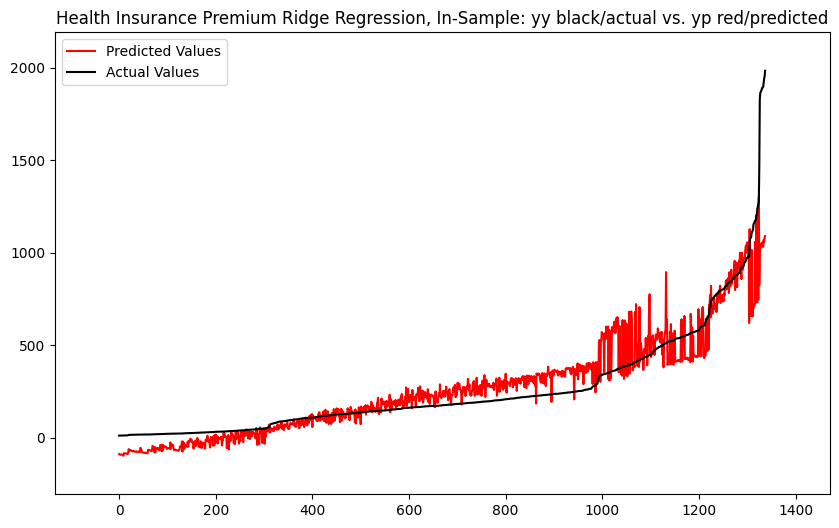

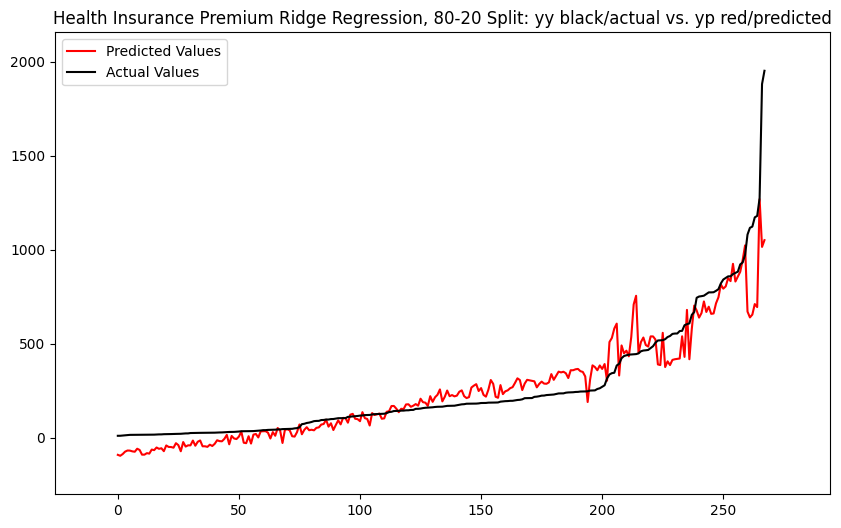

In [7]:
RidRegHealthPrem()

### Lasso Regression Health Premium

\begin{table}[h]
\centering
\caption{Statsmodels - Health Insurance Premium Lasso Regression}
\label{tab:Statsmodels - Health Insurance Premium Lasso Regression}
\begin{tabular}{|c|c|c|}\hline
Regression & In-Sample & 80-20 Split \\ \hline \hline
rSq & 0.8121 & 0.8326 \\ \hline
rSqBar & 0.8104 & 0.8248 \\ \hline
sst & 114413875.8231 & 24801979.3643 \\ \hline
sse & 21500437.2285 & 4150661.8647 \\ \hline
sde & 127.3362 & 124.4490 \\ \hline
mse0 & 85511.1180 & 92544.6991 \\ \hline
rmse & 127.3362 & 124.4490 \\ \hline
mae & 78.9703 & 77.8679 \\ \hline
smape & 58.5812 & 63.7562 \\ \hline
\end{tabular}
\end{table}


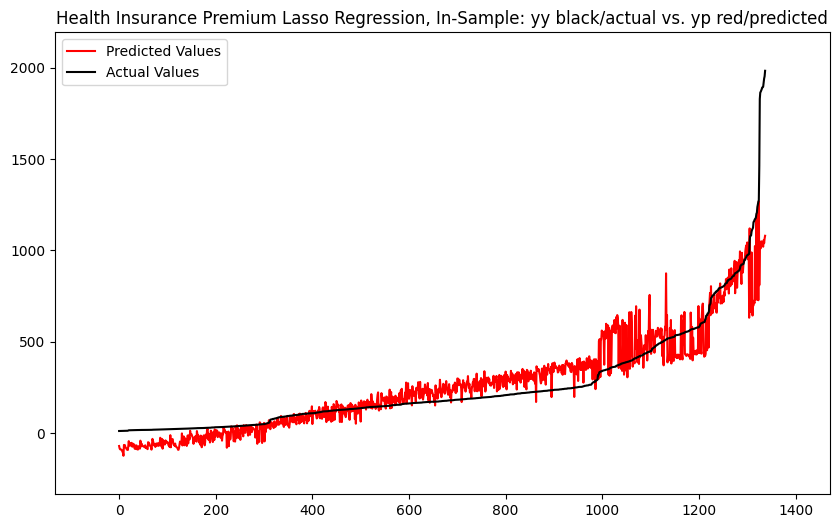

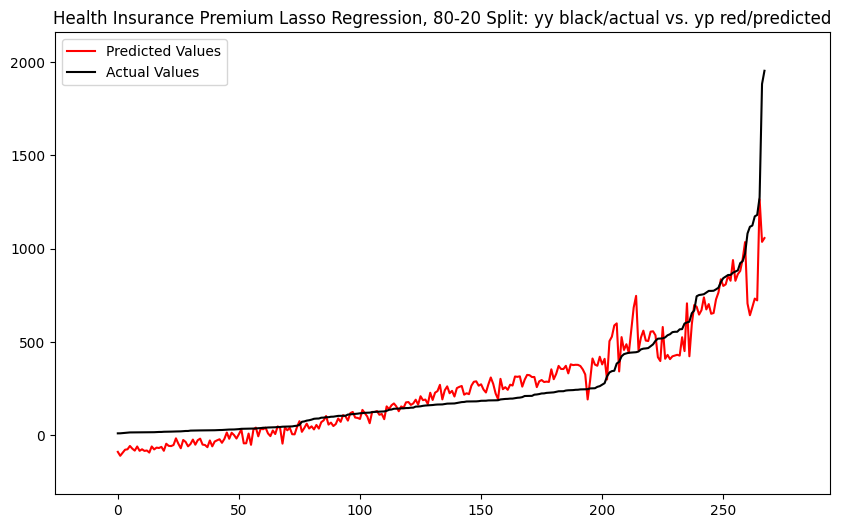

In [8]:
LasRegHealthPrem()

## Regularized Regression on Health Insurance **without** Premium

In [9]:
Xnoprem = Xnoprem.copy()
ynoprem = ynoprem.copy()
Xnoprem = sm.add_constant(Xnoprem)
Xnoprem_tr, Xnoprem_te, ynoprem_tr, ynoprem_te = train_test_split(Xnoprem, ynoprem, test_size=0.2, random_state=42)
def RidRegHealthNoPrem():
    #Add constant and split the data

    #Ridge Regression, model fitting on training and insample data
    ridreginsamp = sm.OLS(ynoprem, Xnoprem).fit_regularized(L1_wt=0)
    ridregtrain = sm.OLS(ynoprem_tr, Xnoprem_tr).fit_regularized(L1_wt=0)
    
    #Use both models to predict on testing
    ridgeypredinsamp = ridreginsamp.predict(Xnoprem)
    ridgeypredtest = ridregtrain.predict(Xnoprem_te)

    #k number of predictors
    k = Xnoprem.shape[1] - 1

    #Print Ridge Regression LaTeX table and sorted plots
    LatexTableRidge(ynoprem, ynoprem_te, ridgeypredinsamp, ridgeypredtest, k, "Health Insurance Premium")
    sorted_plot_ridge(ynoprem, ridgeypredinsamp, "Health Insurance Premium", validate=False)
    sorted_plot_ridge(ynoprem_te, ridgeypredtest, "Health Insurance Premium", validate=True)
def LasRegHealthNoPrem():
    #Lasso Regression, model fitting on training and insample data
    lasreginsamp = sm.OLS(ynoprem, Xnoprem).fit_regularized(L1_wt=1)
    lasregtrain = sm.OLS(ynoprem_tr, Xnoprem_tr).fit_regularized(L1_wt=1)

    #Use both models to predict on testing
    lasypredinsamp = lasreginsamp.predict(Xnoprem)
    lasypredtest = lasregtrain.predict(Xnoprem_te)

    #k number of predictors
    k = Xnoprem.shape[1] - 1

    #Print Lasso Regression LaTeX table and sorted plots
    LatexTableLasso(ynoprem, ynoprem_te, lasypredinsamp, lasypredtest, k, "Health Insurance Premium")
    sorted_plot_lasso(ynoprem, lasypredinsamp, "Health Insurance Premium", validate=False)
    sorted_plot_lasso(ynoprem_te, lasypredtest, "Health Insurance Premium", validate=True)


### Ridge Regression No Health Premium

\begin{table}[h]
\centering
\caption{Statsmodels - Health Insurance Premium Ridge Regression}
\label{tab:Statsmodels - Health Insurance Premium Ridge Regression}
\begin{tabular}{|c|c|c|}\hline
Regression & In-Sample & 80-20 Split \\ \hline \hline
rSq & 0.7481 & 0.7790 \\ \hline
rSqBar & 0.7460 & 0.7696 \\ \hline
sst & 196074221568.3671 & 41606660039.7953 \\ \hline
sse & 49390551250.9356 & 9193060296.4193 \\ \hline
sde & 6100.7956 & 5856.8305 \\ \hline
mse0 & 146542766.4935 & 155248731.4918 \\ \hline
rmse & 6100.7956 & 5856.8305 \\ \hline
mae & 4211.7851 & 4254.3369 \\ \hline
smape & 37.8654 & 39.8069 \\ \hline
\end{tabular}
\end{table}


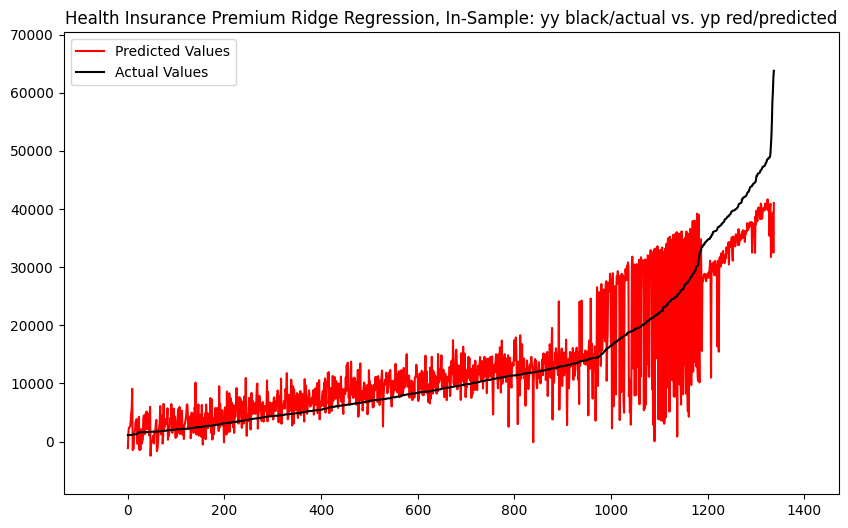

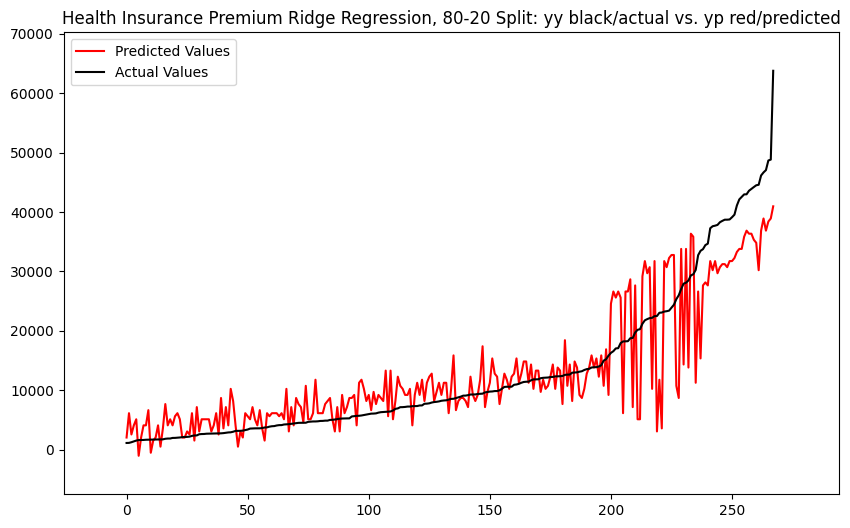

In [10]:
RidRegHealthNoPrem()

### Lasso Regression No Health Premium

\begin{table}[h]
\centering
\caption{Statsmodels - Health Insurance Premium Lasso Regression}
\label{tab:Statsmodels - Health Insurance Premium Lasso Regression}
\begin{tabular}{|c|c|c|}\hline
Regression & In-Sample & 80-20 Split \\ \hline \hline
rSq & 0.7470 & 0.7786 \\ \hline
rSqBar & 0.7449 & 0.7692 \\ \hline
sst & 196074221568.3671 & 41606660039.7953 \\ \hline
sse & 49615673339.1627 & 9209973179.2805 \\ \hline
sde & 6114.6835 & 5862.2156 \\ \hline
mse0 & 146542766.4935 & 155248731.4918 \\ \hline
rmse & 6114.6835 & 5862.2156 \\ \hline
mae & 4019.1879 & 4002.7114 \\ \hline
smape & 32.9050 & 35.1883 \\ \hline
\end{tabular}
\end{table}


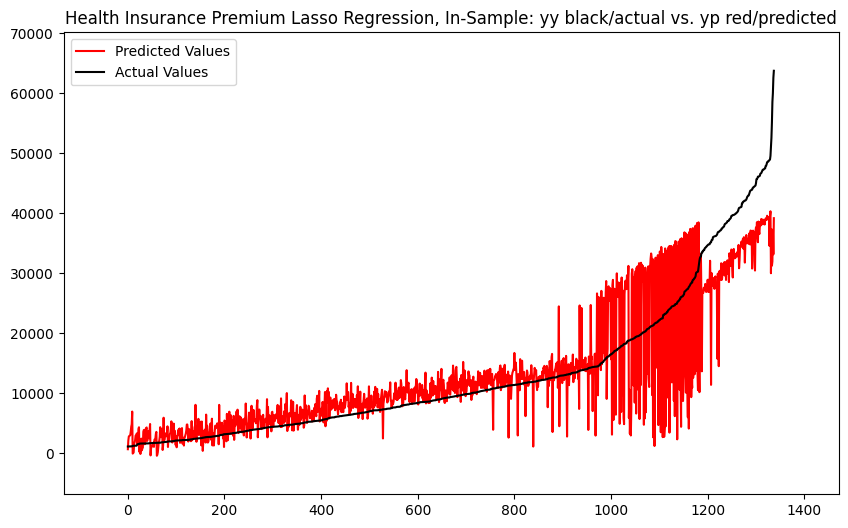

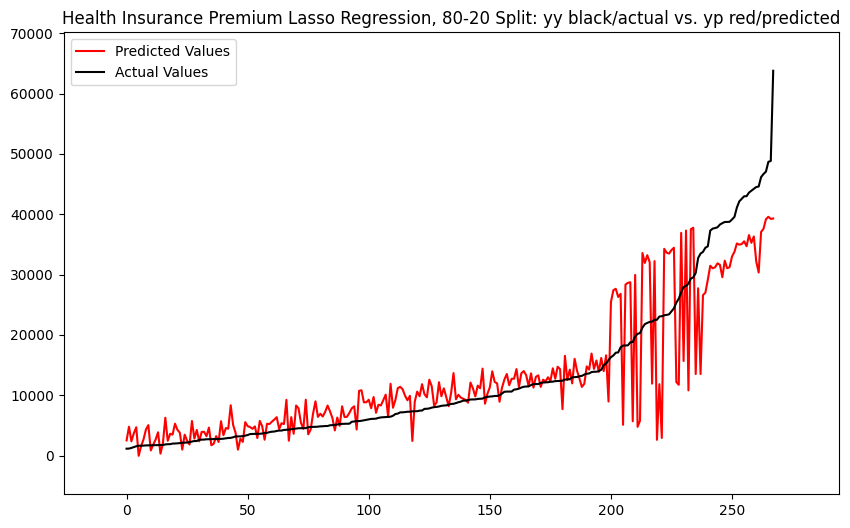

In [11]:
LasRegHealthNoPrem()